<a href="https://colab.research.google.com/github/ashleyholen/Data-Science-Capstone/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clean by 2045?
Forecasting Hawaiʻi’s Renewable Energy Transition**

Ashley Holen, Chaminade University of Honolulu, DS 495 – Data Science Directed Research, Fall 2025

In [408]:
#packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import datetime

In [409]:
#reading in data
energy = pd.read_csv("drive/MyDrive/DS_Capstone/hi_energy.csv")

In [410]:
#looking at first 5 rows
energy.head()

,description,units,source key,Jan-01,Feb-01,Mar-01,Apr-01,May-01,Jun-01,Jul-01,...,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25
0,all fuels (utility-scale),thousand megawatthours,ELEC.GEN.ALL-HI-99.M,925,801,873,836,886,874,936,...,836,758,808,762,667,749,751,737,769,811
1,coal,thousand megawatthours,ELEC.GEN.COW-HI-99.M,134,131,137,111,141,137,138,...,--,--,--,--,--,--,--,--,--,--
2,petroleum liquids,thousand megawatthours,ELEC.GEN.PEL-HI-99.M,726,613,691,653,669,660,725,...,651,584,644,591,513,540,541,505,553,578
3,petroleum coke,thousand megawatthours,ELEC.GEN.PC-HI-99.M,--,--,--,--,--,--,--,...,--,--,--,--,--,--,--,--,--,--
4,natural gas,thousand megawatthours,ELEC.GEN.NG-HI-99.M,0,0,0,0,0,0,0,...,--,--,--,--,--,--,--,--,--,--


In [411]:
# take out units and source key col first

cols_to_drop = ['units', 'source key']
energy = energy.drop(columns=cols_to_drop)

In [412]:
# melt from wide to long format
df_long = energy.melt(
    id_vars=["description"], # keep fuel type
    var_name="date_str", # new column for the old column names
    value_name="net_generation" # new column for values
)


In [413]:
df_long.head()

,description,date_str,net_generation
0,all fuels (utility-scale),Jan-01,925
1,coal,Jan-01,134
2,petroleum liquids,Jan-01,726
3,petroleum coke,Jan-01,--
4,natural gas,Jan-01,0


In [414]:
df_long.tail()


,description,date_str,net_generation
5600,hydro-electric pumped storage,Jul-25,--
5601,other,Jul-25,25
5602,all solar,Jul-25,264
5603,small-scale solar photovoltaic,Jul-25,160
5604,all utility-scale solar,Jul-25,104


In [415]:
df_long

,description,date_str,net_generation
0,all fuels (utility-scale),Jan-01,925
1,coal,Jan-01,134
2,petroleum liquids,Jan-01,726
3,petroleum coke,Jan-01,--
4,natural gas,Jan-01,0
...,...,...,...
5600,hydro-electric pumped storage,Jul-25,--
5601,other,Jul-25,25
5602,all solar,Jul-25,264
5603,small-scale solar photovoltaic,Jul-25,160


In [416]:
# replace '--' and 'NM' with NaN, convert to float
# i don't know what 'NM' stands for... "not metered"?
df_long["net_generation"] = (
    df_long["net_generation"]
    .replace({"--": pd.NA, "NM": pd.NA})
)

df_long["net_generation"] = pd.to_numeric(df_long["net_generation"], errors="coerce")

# convert date_str like "Jan-01" into a real datetime
df_long["date"] = pd.to_datetime(df_long["date_str"], format="%b-%y")
df_long["date"] = df_long["date"].dt.strftime("%b %Y")

# rename description as fuel_type and select final columns to keep
tidy_df = df_long.rename(columns={"description": "fuel_type"})[
    ["date", "fuel_type", "net_generation"]
]

In [417]:
tidy_df.head()

,date,fuel_type,net_generation
0,Jan 2001,all fuels (utility-scale),925.0
1,Jan 2001,coal,134.0
2,Jan 2001,petroleum liquids,726.0
3,Jan 2001,petroleum coke,NaN
4,Jan 2001,natural gas,0.0


In [418]:
tidy_df

,date,fuel_type,net_generation
0,Jan 2001,all fuels (utility-scale),925.0
1,Jan 2001,coal,134.0
2,Jan 2001,petroleum liquids,726.0
3,Jan 2001,petroleum coke,NaN
4,Jan 2001,natural gas,0.0
...,...,...,...
5600,Jul 2025,hydro-electric pumped storage,NaN
5601,Jul 2025,other,25.0
5602,Jul 2025,all solar,264.0
5603,Jul 2025,small-scale solar photovoltaic,160.0


In [419]:
#fixing NA value in 1/2024 for all solar, assuming generation of the month prior, 142.0

tidy_df.loc[
    (tidy_df["date"] == "Jan 2024") & (tidy_df["fuel_type"] == "all solar"),
    "net_generation"
] = 142.0


In [420]:
tidy_df

,date,fuel_type,net_generation
0,Jan 2001,all fuels (utility-scale),925.0
1,Jan 2001,coal,134.0
2,Jan 2001,petroleum liquids,726.0
3,Jan 2001,petroleum coke,NaN
4,Jan 2001,natural gas,0.0
...,...,...,...
5600,Jul 2025,hydro-electric pumped storage,NaN
5601,Jul 2025,other,25.0
5602,Jul 2025,all solar,264.0
5603,Jul 2025,small-scale solar photovoltaic,160.0


In [421]:
#finding net gen totals since 2001 by fuel type

fuel_totals = (
    tidy_df.groupby("fuel_type", as_index=False)["net_generation"]
    .sum(numeric_only=True)
)

fuel_totals

,fuel_type,net_generation
0,all fuels (utility-scale),254822.0
1,all solar,17080.0
2,all utility-scale solar,8662.0
3,biomass,7178.0
4,coal,31448.0
5,conventional hydroelectric,2245.0
6,geothermal,4768.0
7,hydro-electric pumped storage,0.0
8,natural gas,0.0
9,nuclear,0.0


In [422]:
tidy_df["date"] = pd.to_datetime(tidy_df["date"])

/tmp/ipython-input-3106731659.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tidy_df["date"] = pd.to_datetime(tidy_df["date"])


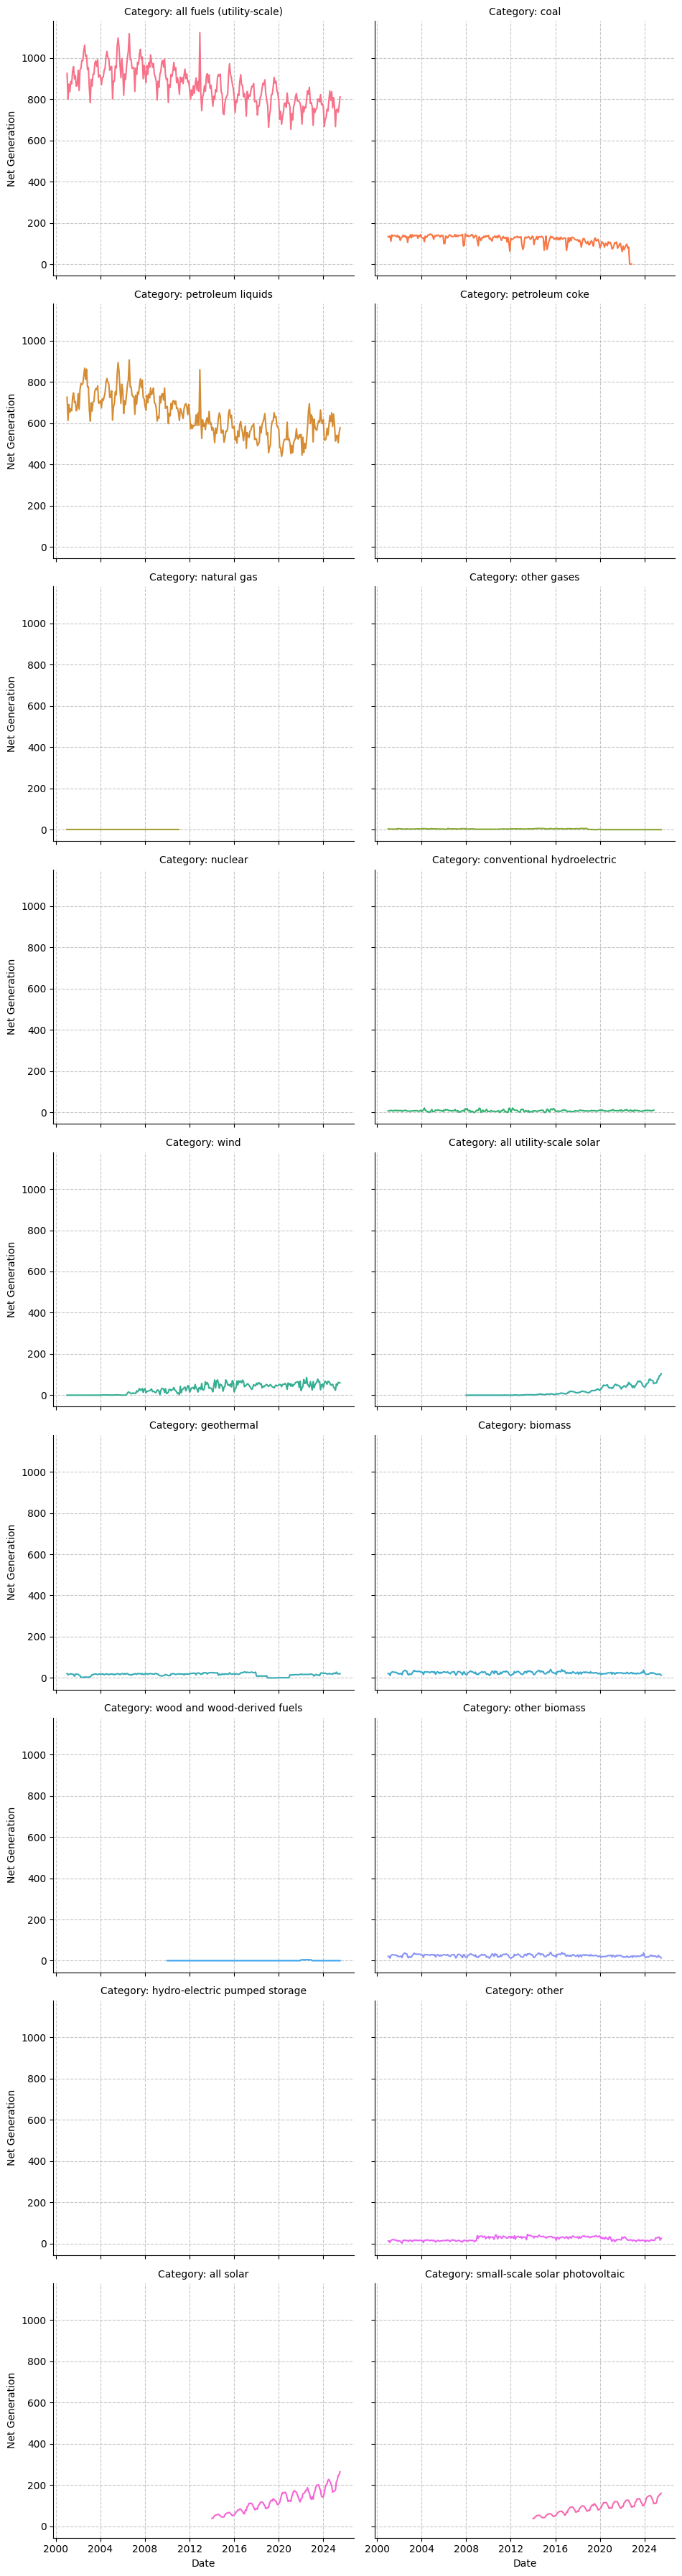

In [423]:
#facet grid
g = sns.FacetGrid(tidy_df, col="fuel_type", hue="fuel_type", col_wrap=2, height=4, aspect=1.2)

#lineplot for each facet
g.map(sns.lineplot, "date", "net_generation")

#axis labels
g.set_axis_labels("Date", "Net Generation")

#facet titles based on col name
g.set_titles(col_template="Category: {col_name}")

#adding gridlines to each subplot
for ax in g.axes.flat:
    ax.grid(True, which='major', linestyle='--', alpha=0.7)

#layout and show
plt.tight_layout()
plt.show()


In [424]:
tidy_df.head()

,date,fuel_type,net_generation
0,2001-01-01,all fuels (utility-scale),925.0
1,2001-01-01,coal,134.0
2,2001-01-01,petroleum liquids,726.0
3,2001-01-01,petroleum coke,NaN
4,2001-01-01,natural gas,0.0


In [425]:
tidy_df["year"] = tidy_df["date"].dt.year

#grouping by year and category, then sum net gen
yearly_sum = (
    tidy_df
    .groupby(["year", "fuel_type"], as_index=False)
    ["net_generation"].sum()
)

yearly_sum

,year,fuel_type,net_generation
0,2001,all fuels (utility-scale),10634.0
1,2001,all solar,0.0
2,2001,all utility-scale solar,0.0
3,2001,biomass,289.0
4,2001,coal,1606.0
...,...,...,...
445,2025,petroleum coke,0.0
446,2025,petroleum liquids,3821.0
447,2025,small-scale solar photovoltaic,976.0
448,2025,wind,340.0


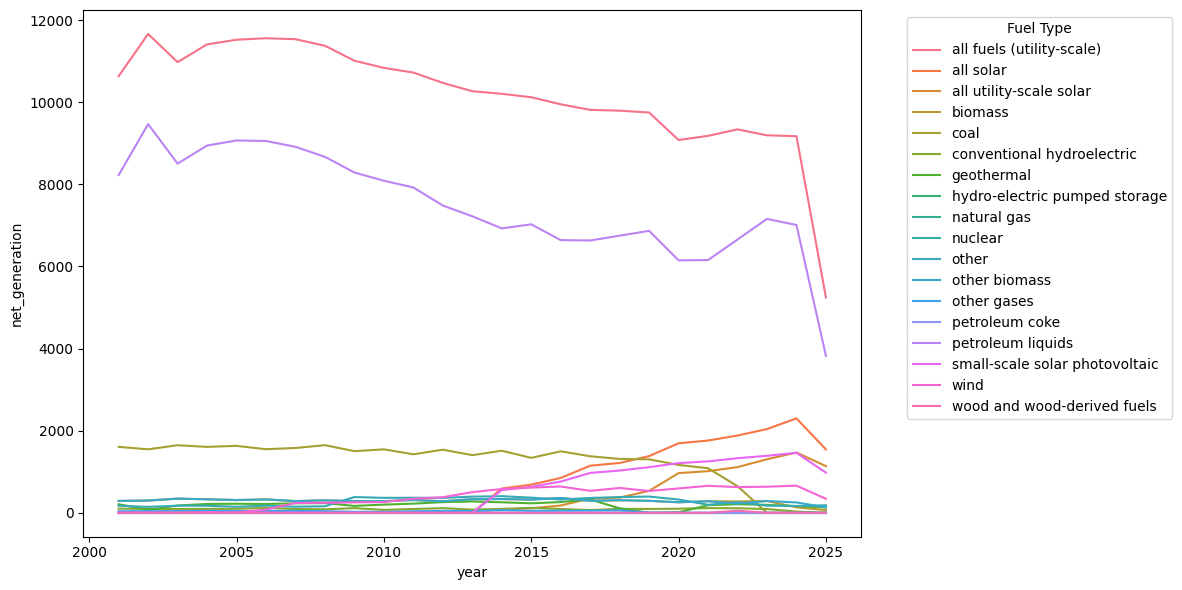

In [426]:
#making the figure larger (width=12, height=6)
plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_sum, x="year", y="net_generation", hue = "fuel_type")

#moving the legend outside the plot
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

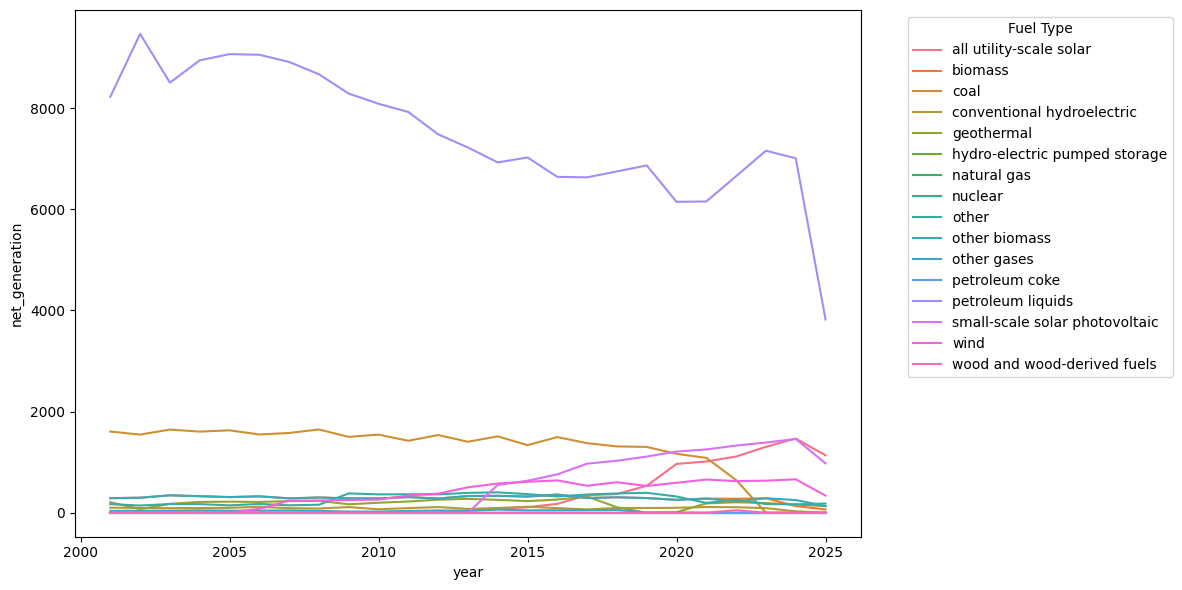

In [427]:
#plot without the all fuels (utility-scale) line
yearly_sum_unique = yearly_sum[~yearly_sum["fuel_type"].isin(["all fuels (utility-scale)", "all solar"])]

plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_sum_unique, x="year", y="net_generation", hue = "fuel_type")

plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

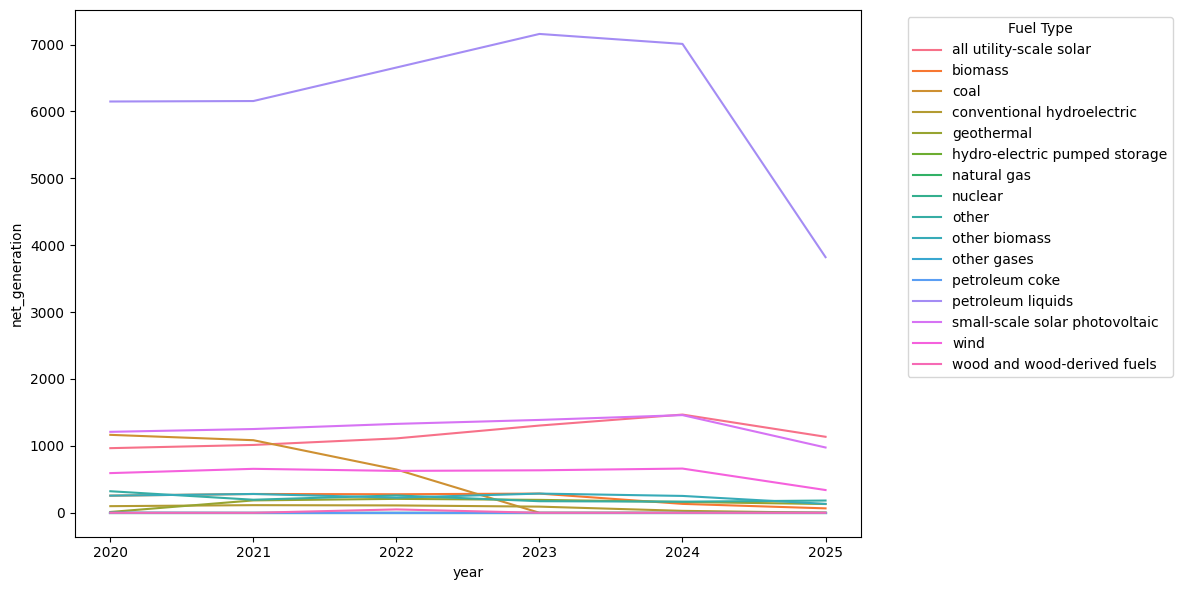

In [428]:
#plot above, but yearly instead of monthly
yearly_sum_unique_five = yearly_sum_unique[(yearly_sum_unique["year"] >= 2020) & (yearly_sum_unique["year"] <= 2025)]

plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_sum_unique_five, x="year", y="net_generation", hue = "fuel_type")

plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [429]:
#does not show much about trend, going to look monthly

monthly_sum_unique = tidy_df[~tidy_df["fuel_type"].isin(["all fuels (utility-scale)", "all solar"])]

monthly_unique_five = monthly_sum_unique[
    (monthly_sum_unique["year"] >= 2020) &
    (monthly_sum_unique["year"] <= 2025)
]

monthly_unique_five


,date,fuel_type,net_generation,year
4333,2020-01-01,coal,79.0,2020
4334,2020-01-01,petroleum liquids,572.0,2020
4335,2020-01-01,petroleum coke,NaN,2020
4336,2020-01-01,natural gas,NaN,2020
4337,2020-01-01,other gases,1.0,2020
...,...,...,...,...
5599,2025-07-01,other biomass,13.0,2025
5600,2025-07-01,hydro-electric pumped storage,NaN,2025
5601,2025-07-01,other,25.0,2025
5603,2025-07-01,small-scale solar photovoltaic,160.0,2025


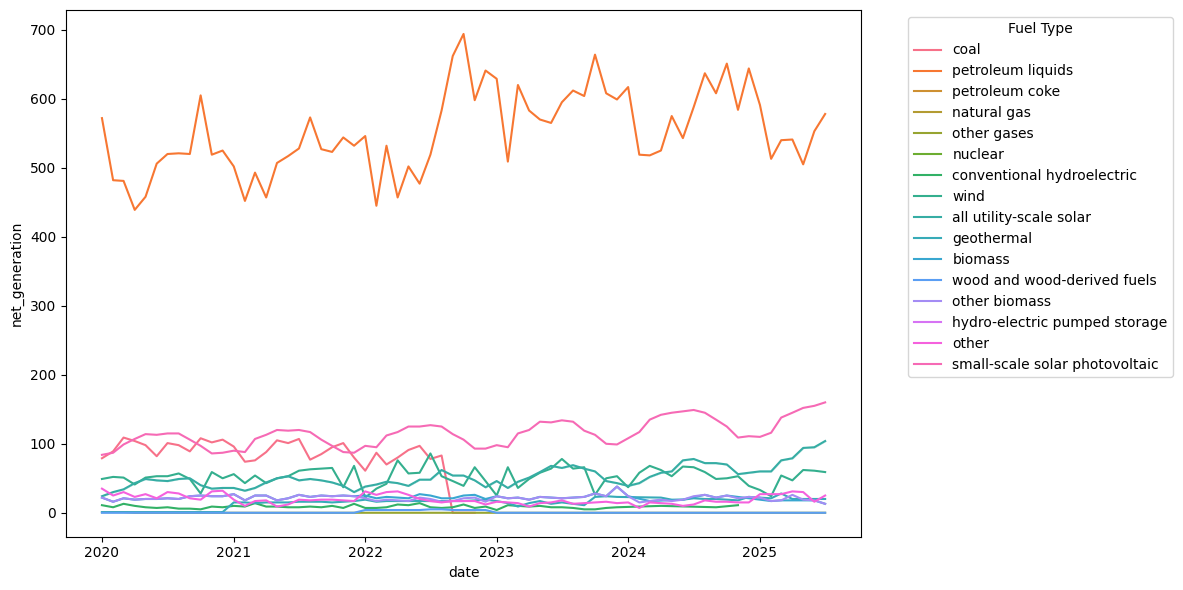

In [430]:
#monthly energy trends, past 5 years
plt.figure(figsize=(12, 6))

sns.lineplot(data=monthly_unique_five, x="date", y="net_generation", hue = "fuel_type")

plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [431]:
tidy_df.head()

,date,fuel_type,net_generation,year
0,2001-01-01,all fuels (utility-scale),925.0,2001
1,2001-01-01,coal,134.0,2001
2,2001-01-01,petroleum liquids,726.0,2001
3,2001-01-01,petroleum coke,NaN,2001
4,2001-01-01,natural gas,0.0,2001


In [432]:
#filtering to only the relevant fuel types
mask = tidy_df["fuel_type"].isin(["total solar", "all fuels (utility-scale)"])

#grouping by date and sum the net_generation for those two fuel types
grand_totals = (
    tidy_df[mask]
    .groupby("date", as_index=False)["net_generation"]
    .sum()
    .rename(columns={"net_generation": "grand_total"})
)

#merging back to tidy_df so each row on the same date gets the total
tidy_df = tidy_df.merge(grand_totals, on="date", how="left")

tidy_df.head()


,date,fuel_type,net_generation,year,grand_total
0,2001-01-01,all fuels (utility-scale),925.0,2001,925.0
1,2001-01-01,coal,134.0,2001,925.0
2,2001-01-01,petroleum liquids,726.0,2001,925.0
3,2001-01-01,petroleum coke,NaN,2001,925.0
4,2001-01-01,natural gas,0.0,2001,925.0


In [433]:
tidy_df.tail()

,date,fuel_type,net_generation,year,grand_total
5600,2025-07-01,hydro-electric pumped storage,NaN,2025,811.0
5601,2025-07-01,other,25.0,2025,811.0
5602,2025-07-01,all solar,264.0,2025,811.0
5603,2025-07-01,small-scale solar photovoltaic,160.0,2025,811.0
5604,2025-07-01,all utility-scale solar,104.0,2025,811.0


In [434]:
tidy_df_totals = tidy_df[["date", "grand_total"]].drop_duplicates().reset_index(drop=True)
tidy_df_totals.head()

,date,grand_total
0,2001-01-01,925.0
1,2001-02-01,801.0
2,2001-03-01,873.0
3,2001-04-01,836.0
4,2001-05-01,886.0


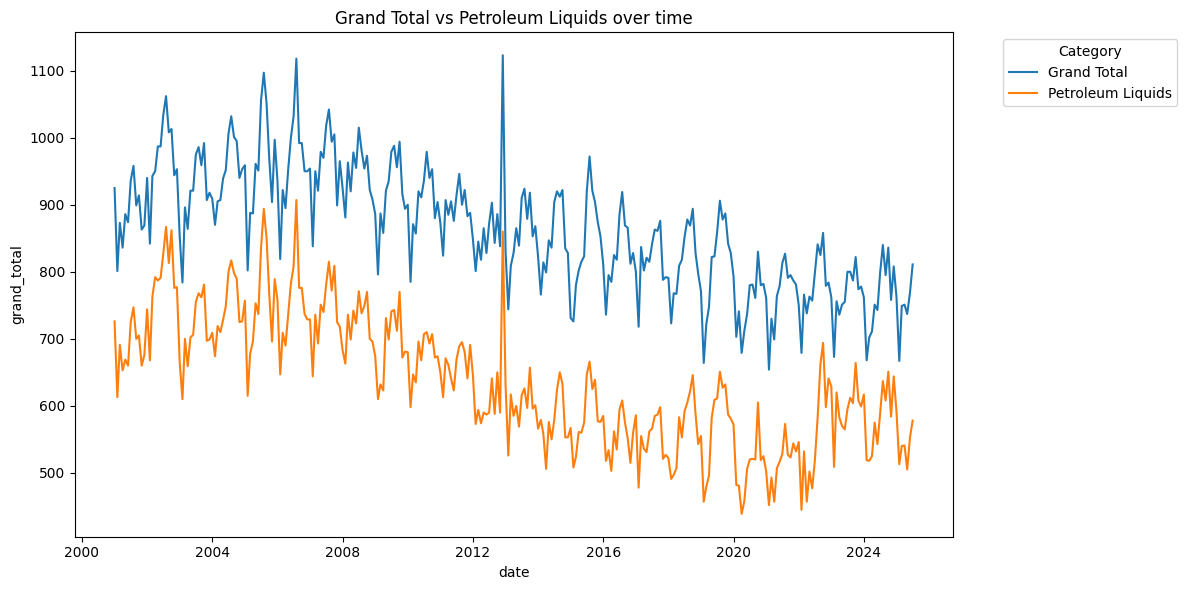

In [435]:
#line graph displaying how much petroleum contributes to overall energy generation
plt.figure(figsize=(12, 6))

#line for total generation
sns.lineplot(data=tidy_df_totals, x="date", y="grand_total", label="Grand Total")

#line for petroleum liquids
sns.lineplot(
    data=tidy_df[tidy_df["fuel_type"] == "petroleum liquids"],
    x="date",
    y="net_generation",
    label="Petroleum Liquids"
)

plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Grand Total vs Petroleum Liquids over time")
plt.tight_layout()
plt.show()

In [436]:
tidy_df.head()

,date,fuel_type,net_generation,year,grand_total
0,2001-01-01,all fuels (utility-scale),925.0,2001,925.0
1,2001-01-01,coal,134.0,2001,925.0
2,2001-01-01,petroleum liquids,726.0,2001,925.0
3,2001-01-01,petroleum coke,NaN,2001,925.0
4,2001-01-01,natural gas,0.0,2001,925.0


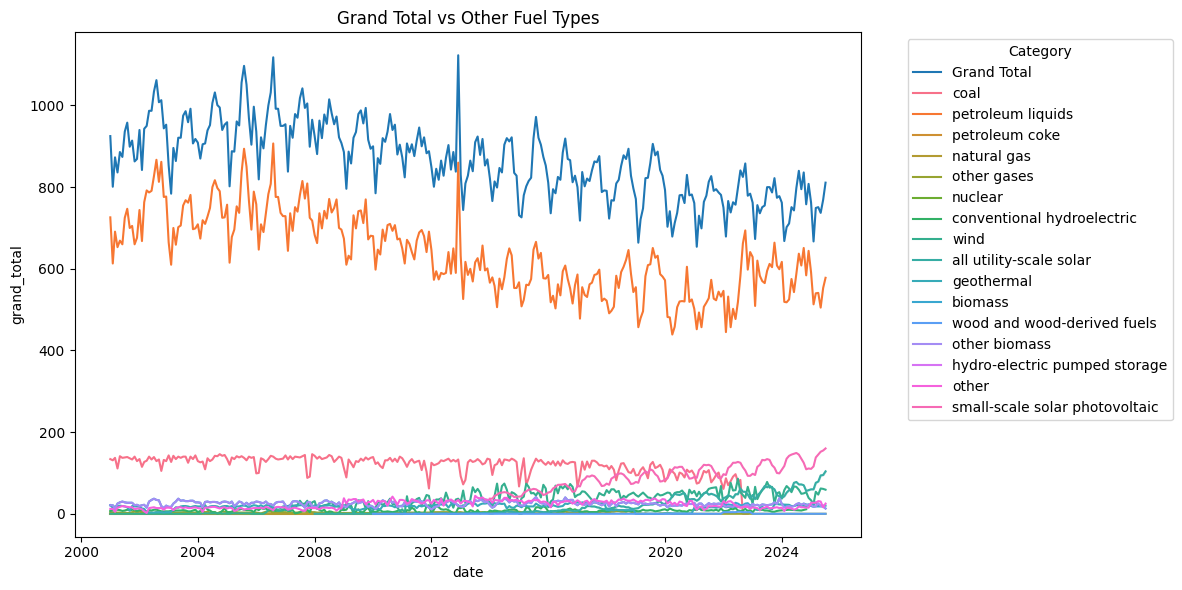

In [437]:
#line graph of total energy generation vs all types
subset = tidy_df[~tidy_df["fuel_type"].isin(["all fuels (utility-scale)"])] #each unique type

plt.figure(figsize=(12, 6))

#grand total
sns.lineplot(data=tidy_df_totals, x="date", y="grand_total", label="Grand Total")

#all other fuel types
sns.lineplot(data=subset[~subset["fuel_type"].isin(["all solar"])], x="date", y="net_generation", hue="fuel_type")

plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Grand Total vs Other Fuel Types")
plt.tight_layout()
plt.show()

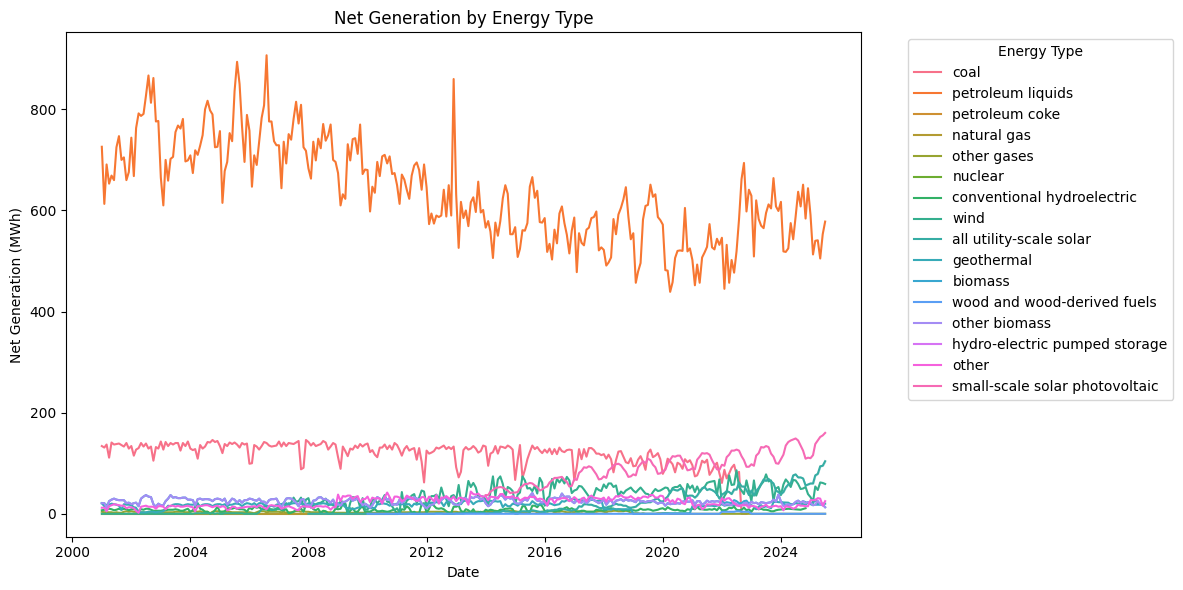

In [438]:
#line graph of generation by energy type, excluding total
plt.figure(figsize=(12, 6))


sns.lineplot(data=subset[~subset["fuel_type"].isin(["all solar"])], x="date", y="net_generation", hue ="fuel_type")


plt.legend(title="Energy Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Net Generation by Energy Type")
plt.xlabel("Date")
plt.ylabel("Net Generation (MWh)")
plt.tight_layout()
plt.show()

In [439]:
subset.head()

,date,fuel_type,net_generation,year,grand_total
1,2001-01-01,coal,134.0,2001,925.0
2,2001-01-01,petroleum liquids,726.0,2001,925.0
3,2001-01-01,petroleum coke,NaN,2001,925.0
4,2001-01-01,natural gas,0.0,2001,925.0
5,2001-01-01,other gases,4.0,2001,925.0


In [440]:
#take out the negligible energy types, group into non-renewable and renewable. non-renewable only includes coal and petroleum

final_types = subset[~subset["fuel_type"].isin([
    "other gases",
    "all utility-scale solar",
    "small-scale solar photovoltaic",
    "petroleum coke",
    "nuclear",
    "hydro-electric pumped storage",
    "wood and wood-derived fuels",
    "natural gas",
])]

In [441]:
print(final_types['fuel_type'].drop_duplicates().reset_index(drop=True))

0                          coal
1             petroleum liquids
2    conventional hydroelectric
3                          wind
4                    geothermal
5                       biomass
6                 other biomass
7                         other
8                     all solar
Name: fuel_type, dtype: object


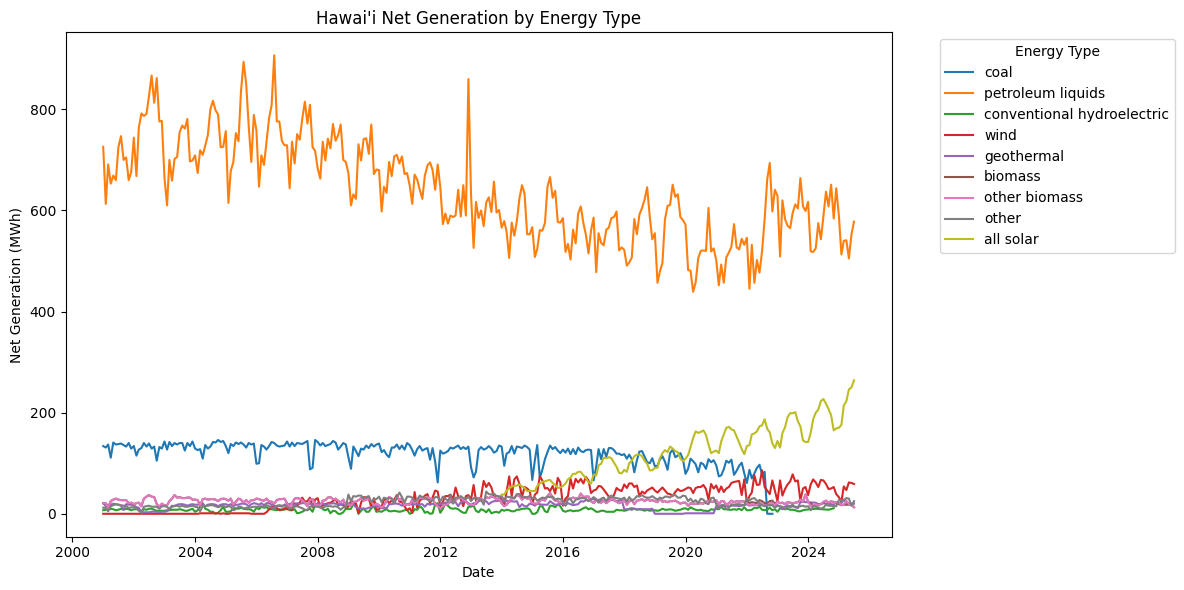

In [442]:
#generation by simplifed energy types
plt.figure(figsize=(12, 6))


sns.lineplot(data=final_types, x="date", y="net_generation", hue ="fuel_type")


plt.legend(title="Energy Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Hawai'i Net Generation by Energy Type")
plt.xlabel("Date")
plt.ylabel("Net Generation (MWh)")
plt.tight_layout()
plt.show()

In [443]:
final_types.head()

,date,fuel_type,net_generation,year,grand_total
1,2001-01-01,coal,134.0,2001,925.0
2,2001-01-01,petroleum liquids,726.0,2001,925.0
7,2001-01-01,conventional hydroelectric,7.0,2001,925.0
8,2001-01-01,wind,0.0,2001,925.0
10,2001-01-01,geothermal,21.0,2001,925.0


In [444]:
#group by year, then by renewable or non

annual_totals = (
    final_types.groupby(["year", "fuel_type"], as_index=False)["net_generation"]
         .sum()
)

annual_totals.head()

,year,fuel_type,net_generation
0,2001,all solar,0.0
1,2001,biomass,289.0
2,2001,coal,1606.0
3,2001,conventional hydroelectric,101.0
4,2001,geothermal,208.0


<Axes: xlabel='year', ylabel='net_generation'>

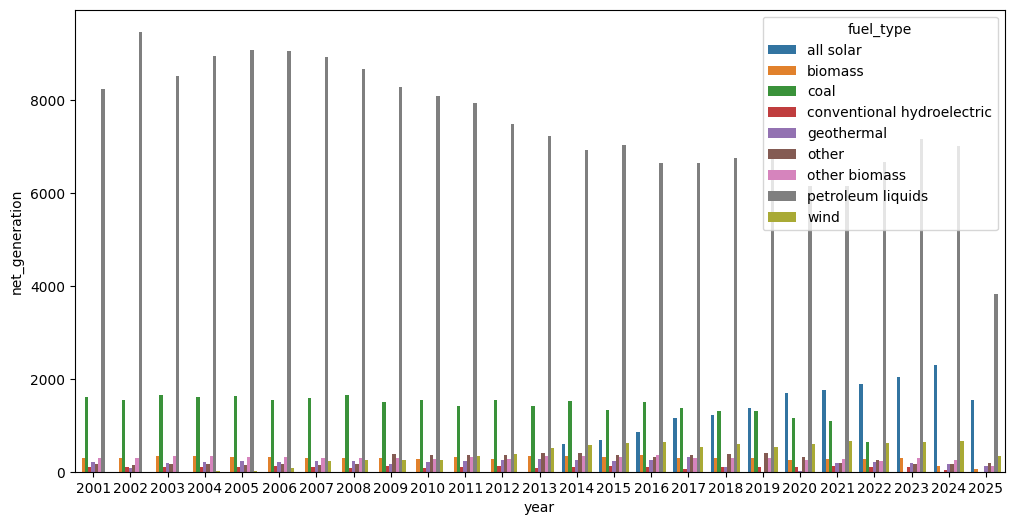

In [445]:
#annual energy generation totals by type
plt.figure(figsize=(12, 6))

sns.barplot(data = annual_totals, x= "year", y= "net_generation", hue= "fuel_type")

In [446]:
#creating a category column (renewable/nonrenewable)
non_renewable_list = ["petroleum liquids", "coal"]

annual_totals["category"] = np.where(
    annual_totals["fuel_type"].isin(non_renewable_list),
    "non_renewable",
    "renewable"
)

annual_totals.head()

,year,fuel_type,net_generation,category
0,2001,all solar,0.0,renewable
1,2001,biomass,289.0,renewable
2,2001,coal,1606.0,non_renewable
3,2001,conventional hydroelectric,101.0,renewable
4,2001,geothermal,208.0,renewable


In [447]:
#totals by category
category_totals = (
    annual_totals
        .groupby(["year", "category"], as_index=False)["net_generation"]
        .sum()
)

#taking out 2025, as it is an incomplete year
category_totals.drop(category_totals[category_totals["year"] == 2025].index, inplace=True)

category_totals.head()


,year,category,net_generation
0,2001,non_renewable,9831.0
1,2001,renewable,1058.0
2,2002,non_renewable,11013.0
3,2002,renewable,908.0
4,2003,non_renewable,10149.0


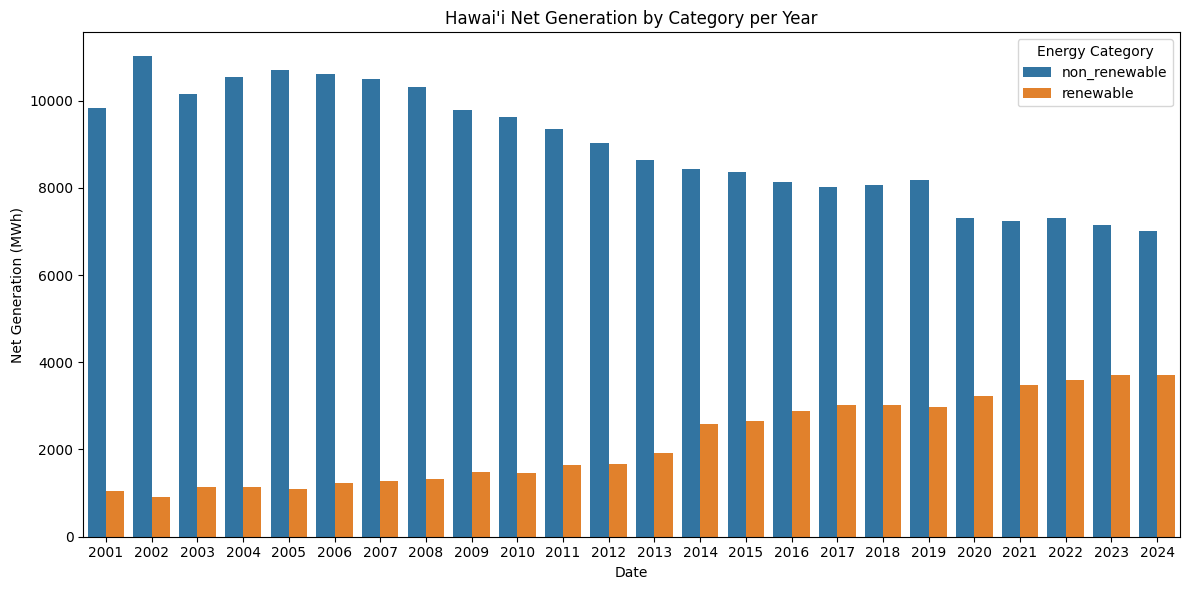

In [448]:
#bar graph of renewable vs nonrenewable in HI per year
plt.figure(figsize=(12, 6))

sns.barplot(data = category_totals, x= "year", y= "net_generation", hue= "category")

plt.legend(title="Energy Category")
plt.title("Hawai'i Net Generation by Category per Year")
plt.xlabel("Date")
plt.ylabel("Net Generation (MWh)")
plt.tight_layout()
plt.show()

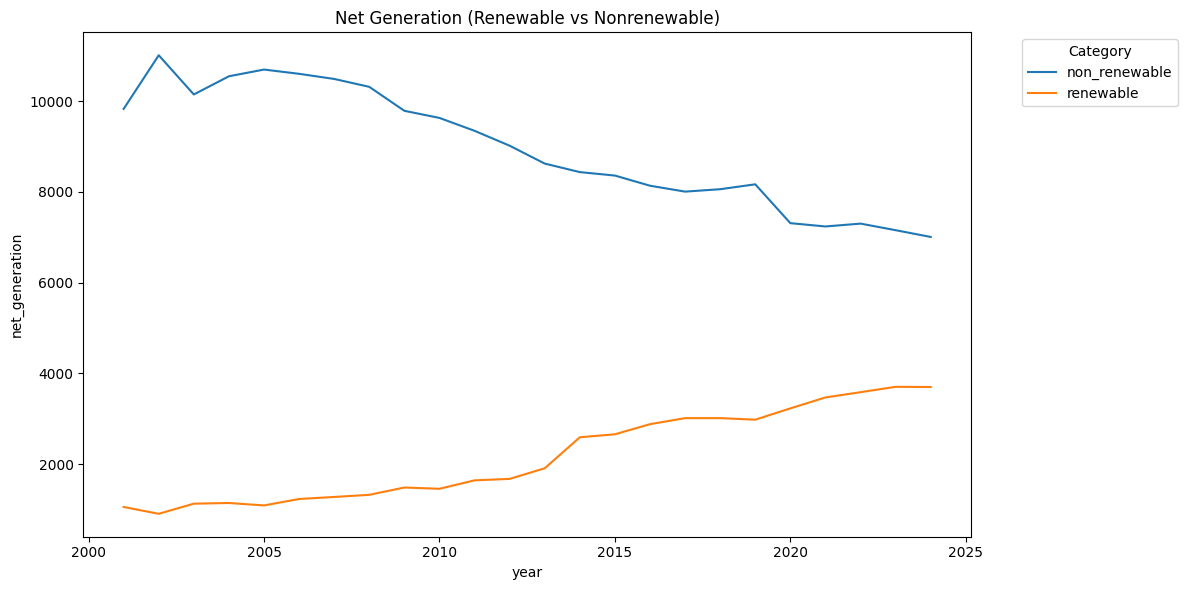

In [449]:
#line graph of of renewable vs nonrenewable in HI per year
plt.figure(figsize=(12, 6))


sns.lineplot(data = category_totals, x= "year", y= "net_generation", hue= "category")


plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Net Generation (Renewable vs Nonrenewable)")
plt.tight_layout()
plt.show()

In [450]:
category_totals.head()

,year,category,net_generation
0,2001,non_renewable,9831.0
1,2001,renewable,1058.0
2,2002,non_renewable,11013.0
3,2002,renewable,908.0
4,2003,non_renewable,10149.0


In [451]:
#pivoting to create a difference column (nonrenewable-renewable)
ml_data = category_totals.pivot(
    index="year",
    columns="category",
    values="net_generation"
).reset_index()

ml_data.columns.name = None

ml_data["difference"] = ml_data["non_renewable"] - ml_data["renewable"]

ml_data.head()

,year,non_renewable,renewable,difference
0,2001,9831.0,1058.0,8773.0
1,2002,11013.0,908.0,10105.0
2,2003,10149.0,1131.0,9018.0
3,2004,10550.0,1146.0,9404.0
4,2005,10698.0,1092.0,9606.0


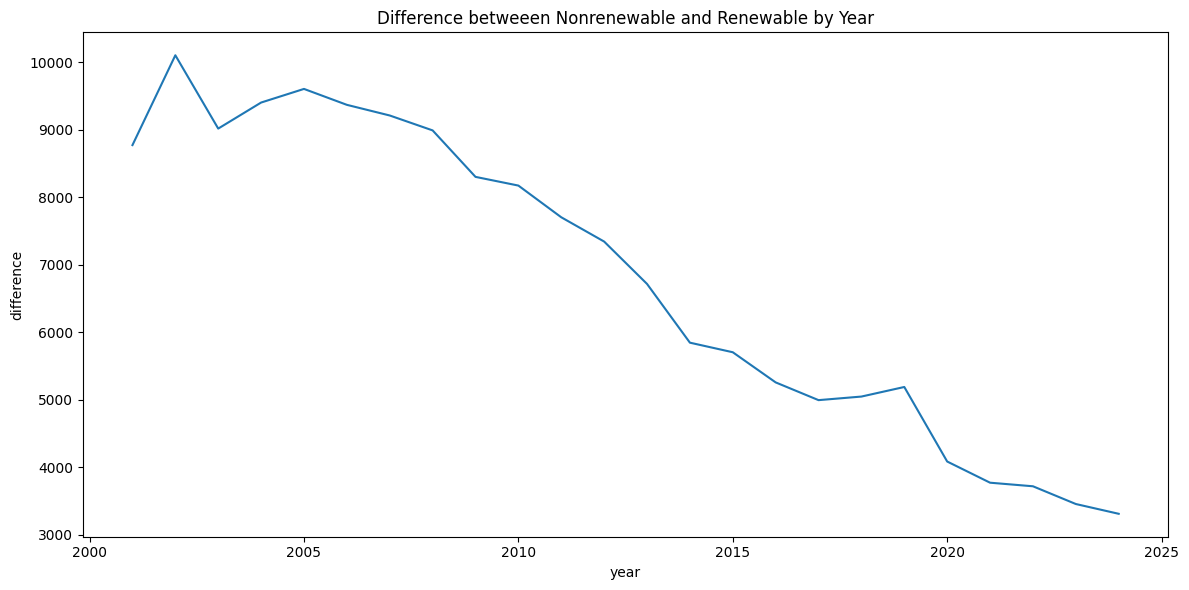

In [452]:
#line graph of the difference between categories (nonrenewable-renewable)
plt.figure(figsize=(12, 6))


sns.lineplot(data = ml_data, x= "year", y= "difference")

plt.title("Difference betweeen Nonrenewable and Renewable by Year")
plt.tight_layout()
plt.show()

In [453]:
#linear Regression Machine Learning Model BY YEAR
#looking at when difference (nonrenewable - renewable) <=0

ml_data["year"] = ml_data["year"].astype(int)
ml_data = ml_data.sort_values("year")

#train test split 80%
split_point = int(len(ml_data) * 0.8)
train = ml_data.iloc[:split_point]
test  = ml_data.iloc[split_point:]

X_train = train[["year"]]
y_train = train["difference"]
X_test  = test[["year"]]
y_test  = test["difference"]

model1 = LinearRegression()
model1.fit(X_train, y_train)

test_preds = model1.predict(X_test)

mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Model Evaluation:")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("\nTest data vs predictions:")
print(pd.DataFrame({"year": X_test.values.flatten(),
                   "actual": y_test.values,
                   "predicted": test_preds}))

Model Evaluation:
MAE: 356.46
RMSE: 393.86

Test data vs predictions:
   year  actual    predicted
0  2020  4082.0  4620.701754
1  2021  3768.0  4320.982456
2  2022  3715.0  4021.263158
3  2023  3452.0  3721.543860
4  2024  3307.0  3421.824561


In [454]:
#predicting future values using model
future_years = np.arange(ml_data["year"].min(), 2050).reshape(-1, 1)
future_preds = model1.predict(future_years)

#finding first year where renewable ≥ non-renewable (difference ≤ 0)
crossover = np.where(future_preds <= 0)[0]

forecast_df = pd.DataFrame({
    "year": future_years.flatten(),
    "pred_difference": future_preds
})

if len(crossover) > 0:
    crossover_year = int(future_years[crossover[0]][0])
    print("The year that renewables will surpass nonrenewables is HI is:", crossover_year)
else:
    print("None before 2050")

#result is the year 2036

The year that renewables will surpass nonrenewables is HI is: 2036


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [455]:
final_types

,date,fuel_type,net_generation,year,grand_total
1,2001-01-01,coal,134.0,2001,925.0
2,2001-01-01,petroleum liquids,726.0,2001,925.0
7,2001-01-01,conventional hydroelectric,7.0,2001,925.0
8,2001-01-01,wind,0.0,2001,925.0
10,2001-01-01,geothermal,21.0,2001,925.0
...,...,...,...,...,...
5596,2025-07-01,geothermal,20.0,2025,811.0
5597,2025-07-01,biomass,13.0,2025,811.0
5599,2025-07-01,other biomass,13.0,2025,811.0
5601,2025-07-01,other,25.0,2025,811.0


In [456]:
#wanted to look at the same model monthly to incorporate more data points and increase detail
#adding the category column to the monthly df
non_renewable_list = ["petroleum liquids", "coal"]

final_types["category"] = np.where(
    final_types["fuel_type"].isin(non_renewable_list),
    "non_renewable",
    "renewable"
)

final_types.head()

/tmp/ipython-input-1705629314.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_types["category"] = np.where(


,date,fuel_type,net_generation,year,grand_total,category
1,2001-01-01,coal,134.0,2001,925.0,non_renewable
2,2001-01-01,petroleum liquids,726.0,2001,925.0,non_renewable
7,2001-01-01,conventional hydroelectric,7.0,2001,925.0,renewable
8,2001-01-01,wind,0.0,2001,925.0,renewable
10,2001-01-01,geothermal,21.0,2001,925.0,renewable


In [457]:
final_types = final_types.drop(['year', 'grand_total'], axis=1)

In [458]:
final_types.head()

,date,fuel_type,net_generation,category
1,2001-01-01,coal,134.0,non_renewable
2,2001-01-01,petroleum liquids,726.0,non_renewable
7,2001-01-01,conventional hydroelectric,7.0,renewable
8,2001-01-01,wind,0.0,renewable
10,2001-01-01,geothermal,21.0,renewable


In [459]:
#getting df configured for ml
ml_data_monthly = (
    final_types
    .groupby(["date", "category"], as_index=False)["net_generation"]
    .sum()
    .pivot(index="date", columns="category", values="net_generation")
    .reset_index()
)


ml_data_monthly.columns.name = None

#creating difference column
ml_data_monthly["difference"] = (
    ml_data_monthly["non_renewable"] - ml_data_monthly["renewable"]
)

ml_data_monthly.head()


,date,non_renewable,renewable,difference
0,2001-01-01,860.0,82.0,778.0
1,2001-02-01,744.0,77.0,667.0
2,2001-03-01,828.0,55.0,773.0
3,2001-04-01,764.0,93.0,671.0
4,2001-05-01,810.0,102.0,708.0


<Axes: xlabel='date', ylabel='renewable'>

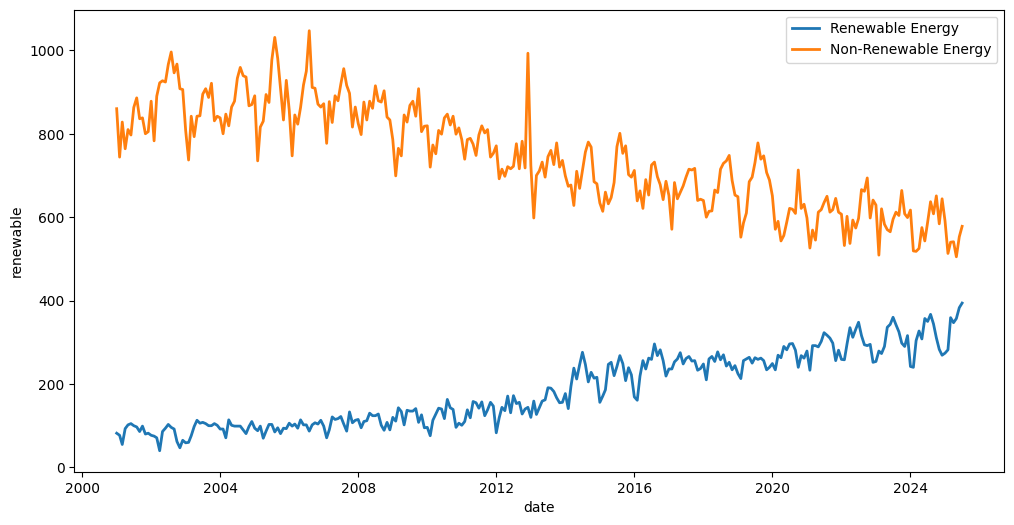

In [460]:
#line graph of renewable vs nonrenewable, monthly
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ml_data_monthly,
    x="date",
    y="renewable",
    label="Renewable Energy",
    linewidth=2
)

sns.lineplot(
    data=ml_data_monthly,
    x="date",
    y="non_renewable",
    label="Non-Renewable Energy",
    linewidth=2
)

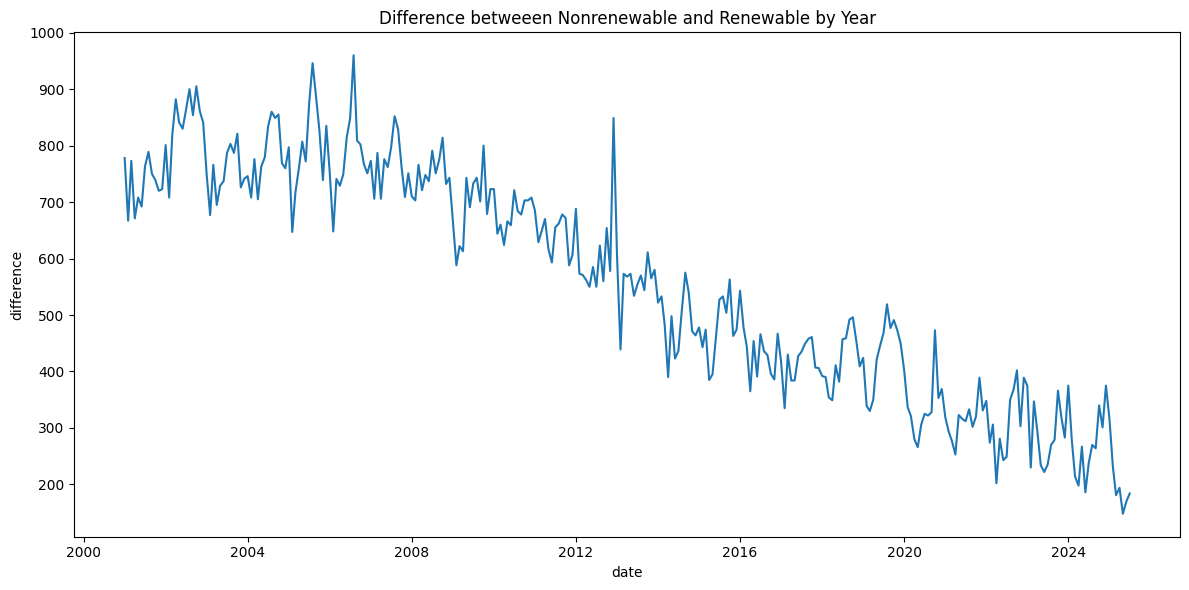

In [461]:
#line graph of difference (nonrenewable - renewable) monthly
plt.figure(figsize=(12, 6))


sns.lineplot(data = ml_data_monthly, x= "date", y= "difference")

plt.title("Difference betweeen Nonrenewable and Renewable by Year")
plt.tight_layout()
plt.show()

Linear Regression Model

In [462]:
# Linear Regression Machine Learning Model
# Looking at when difference (nonrenewable - renewable) <=0

# Make sure date is datetime
ml_data_monthly["date"] = pd.to_datetime(ml_data_monthly["date"])
ml_data_monthly = ml_data_monthly.sort_values("date")

# Create numeric time feature for regression (months since start)
ml_data_monthly["time_index"] = np.arange(len(ml_data_monthly))

# Split data 80/20
split_point = int(len(ml_data_monthly) * 0.8)
train = ml_data_monthly.iloc[:split_point]
test  = ml_data_monthly.iloc[split_point:]

X_train = train[["time_index"]]
y_train = train["difference"]
X_test  = test[["time_index"]]
y_test  = test["difference"]

# Train model
model2 = LinearRegression()
model2.fit(X_train, y_train)

# Predict on test data
test_preds = model2.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Model Evaluation:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

# Print results with readable date
results = pd.DataFrame({
    "date": test["date"].dt.strftime("%Y-%m"),
    "actual": y_test.values,
    "predicted": test_preds
})

#print("\nTest data vs predictions:")
#print(results)

Model Evaluation:
MAE: 51.87
RMSE: 60.8


In [463]:
future_steps = 25 * 12  # 25 years of months
future_index = np.arange(len(ml_data_monthly), len(ml_data_monthly) + future_steps).reshape(-1, 1)

# Generate future monthly dates
future_dates = pd.date_range(
    start=ml_data_monthly["date"].max() + pd.offsets.MonthBegin(1),
    periods=future_steps,
    freq="MS"
)

# Predict differences
future_preds = model2.predict(future_index)

# Build forecast DataFrame
forecast_df = pd.DataFrame({
    "date": future_dates,
    "pred_difference": future_preds
})

# --- Find crossover point (where renewables ≥ non-renewables) ---
crossover = np.where(future_preds <= 0)[0]

if len(crossover) > 0:
    crossover_date = forecast_df.iloc[crossover[0]]["date"]
    print("The month renewables will surpass nonrenewables in HI is:", crossover_date.strftime("%Y-%m"))
else:
    print("No crossover predicted in the next 25 years.")

# Optional: show sample forecast
print("\nForecast sample:")
print(forecast_df.head(12))

#result is May 2035


The month renewables will surpass nonrenewables in HI is: 2035-05

Forecast sample:
         date  pred_difference
0  2025-08-01       247.683937
1  2025-09-01       245.563011
2  2025-10-01       243.442085
3  2025-11-01       241.321159
4  2025-12-01       239.200233
5  2026-01-01       237.079307
6  2026-02-01       234.958381
7  2026-03-01       232.837455
8  2026-04-01       230.716529
9  2026-05-01       228.595603
10 2026-06-01       226.474677
11 2026-07-01       224.353751


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Monthly SARIMAX Model - All dates

In [464]:
ml_data_monthly

,date,non_renewable,renewable,difference,time_index
0,2001-01-01,860.0,82.0,778.0,0
1,2001-02-01,744.0,77.0,667.0,1
2,2001-03-01,828.0,55.0,773.0,2
3,2001-04-01,764.0,93.0,671.0,3
4,2001-05-01,810.0,102.0,708.0,4
...,...,...,...,...,...
290,2025-03-01,540.0,359.0,181.0,290
291,2025-04-01,541.0,347.0,194.0,291
292,2025-05-01,505.0,357.0,148.0,292
293,2025-06-01,553.0,383.0,170.0,293


In [465]:
#creating a renewable share column, will use as a variable for the model
#wanting to predict when renewable share =.5 or 50%
ml_data_monthly['total'] = ml_data_monthly['non_renewable'] + ml_data_monthly['renewable']
ml_data_monthly['renewable_share'] = ml_data_monthly['renewable'] / ml_data_monthly['total']

ml_data_monthly.head()

,date,non_renewable,renewable,difference,time_index,total,renewable_share
0,2001-01-01,860.0,82.0,778.0,0,942.0,0.087049
1,2001-02-01,744.0,77.0,667.0,1,821.0,0.093788
2,2001-03-01,828.0,55.0,773.0,2,883.0,0.062288
3,2001-04-01,764.0,93.0,671.0,3,857.0,0.108518
4,2001-05-01,810.0,102.0,708.0,4,912.0,0.111842


In [466]:
#creating a post_coal column, if the date is after 9/1/2022 since that is when coal production officially ended in HI
ml_data_monthly['post_coal'] = (ml_data_monthly['date'] >= '2022-09-01').astype(int)

ml_data_monthly.head()

,date,non_renewable,renewable,difference,time_index,total,renewable_share,post_coal
0,2001-01-01,860.0,82.0,778.0,0,942.0,0.087049,0
1,2001-02-01,744.0,77.0,667.0,1,821.0,0.093788,0
2,2001-03-01,828.0,55.0,773.0,2,883.0,0.062288,0
3,2001-04-01,764.0,93.0,671.0,3,857.0,0.108518,0
4,2001-05-01,810.0,102.0,708.0,4,912.0,0.111842,0


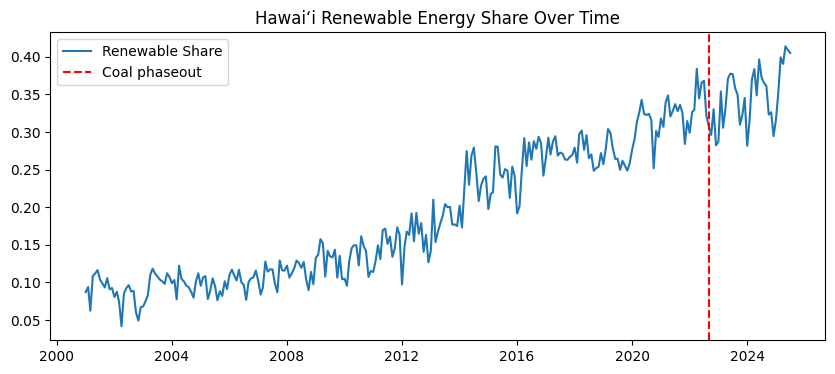

In [467]:
#renewable energy share over time, with red line showing when coal plant shut down
plt.figure(figsize=(10,4))

plt.plot(ml_data_monthly['date'], ml_data_monthly['renewable_share'], label='Renewable Share')
plt.axvline(pd.to_datetime('2022-09-01'), color='red', linestyle='--', label='Coal phaseout')
plt.title("Hawaiʻi Renewable Energy Share Over Time")
plt.legend()
plt.show()

In [468]:
# Define target and exog event (post_coal)
y = ml_data_monthly.set_index('date')['renewable_share']
exog = ml_data_monthly.set_index('date')[['post_coal']]

# Fit SARIMAX
model = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12), exog=exog)
fit = model.fit(disp=False)
print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    renewable_share   No. Observations:                  295
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 688.053
Date:                            Thu, 11 Dec 2025   AIC                          -1364.106
Time:                                    09:40:12   BIC                          -1342.255
Sample:                                01-01-2001   HQIC                         -1355.343
                                     - 07-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
post_coal     -0.0197      0.015     -1.324      0.186      -0.049       0.009
ar.L1          0.2192      0.088   

In [469]:
#predicting 300 steps (months) ahead
steps = 300
future_dates = pd.date_range(start=ml_data_monthly['date'].max(), periods=steps+1, freq='M')[1:]
future_exog = pd.DataFrame({'post_coal': 1}, index=future_dates)

forecast = fit.get_forecast(steps=steps, exog=future_exog)
pred_mean = forecast.predicted_mean.clip(0, 1)  # keep within 0-1 range

/tmp/ipython-input-1626411502.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=ml_data_monthly['date'].max(), periods=steps+1, freq='M')[1:]


In [470]:
#combine past + forecast
combined = pd.concat([y, pred_mean.rename('forecast')])

#first time forecast >= 0.5 (i.e., renewables ≥ nonrenewables)
crossover = combined[combined >= 0.5].index[0]
print(f"Renewables projected to meet/exceed nonrenewables in {crossover.year}.")

#result is the year 2031

Renewables projected to meet/exceed nonrenewables in 2031.


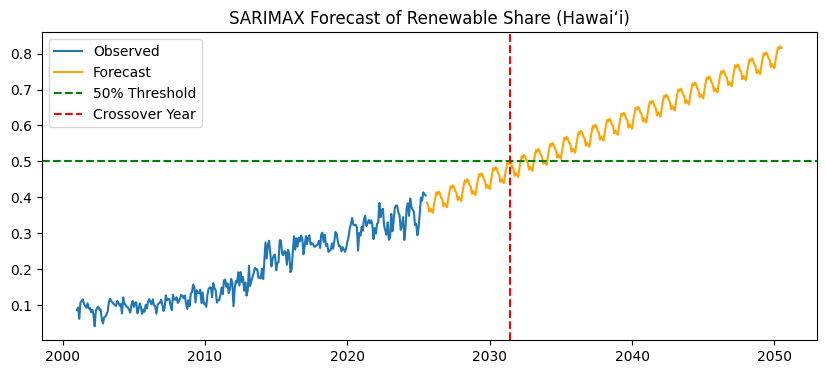

In [471]:
plt.figure(figsize=(10,4))

plt.plot(ml_data_monthly['date'], y, label='Observed')
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='orange')
plt.axhline(0.5, color='green', linestyle='--', label='50% Threshold')
plt.axvline(crossover, color='red', linestyle='--', label='Crossover Year')
plt.legend()
plt.title("SARIMAX Forecast of Renewable Share (Hawaiʻi)")
plt.show()

 Monthly - Past 10 Years SARIMAX. Noticed adoption trend of renewables having a steep slope due to the progression from 0, so a more realistic approach is looking at only the past 10 years since it has leveled out

In [472]:
ml_data_monthly.head()

,date,non_renewable,renewable,difference,time_index,total,renewable_share,post_coal
0,2001-01-01,860.0,82.0,778.0,0,942.0,0.087049,0
1,2001-02-01,744.0,77.0,667.0,1,821.0,0.093788,0
2,2001-03-01,828.0,55.0,773.0,2,883.0,0.062288,0
3,2001-04-01,764.0,93.0,671.0,3,857.0,0.108518,0
4,2001-05-01,810.0,102.0,708.0,4,912.0,0.111842,0


In [473]:
#subsetting to only the past 10 years
latest_date = ml_data_monthly["date"].max()
cutoff = latest_date - pd.DateOffset(years=10)

ml_last10 = ml_data_monthly[ml_data_monthly["date"] >= cutoff]


ml_last10

,date,non_renewable,renewable,difference,time_index,total,renewable_share,post_coal
174,2015-07-01,769.0,242.0,527.0,174,1011.0,0.239367,0
175,2015-08-01,801.0,268.0,533.0,175,1069.0,0.250702,0
176,2015-09-01,753.0,249.0,504.0,176,1002.0,0.248503,0
177,2015-10-01,771.0,208.0,563.0,177,979.0,0.212462,0
178,2015-11-01,702.0,239.0,463.0,178,941.0,0.253985,0
...,...,...,...,...,...,...,...,...
290,2025-03-01,540.0,359.0,181.0,290,899.0,0.399333,1
291,2025-04-01,541.0,347.0,194.0,291,888.0,0.390766,1
292,2025-05-01,505.0,357.0,148.0,292,862.0,0.414153,1
293,2025-06-01,553.0,383.0,170.0,293,936.0,0.409188,1


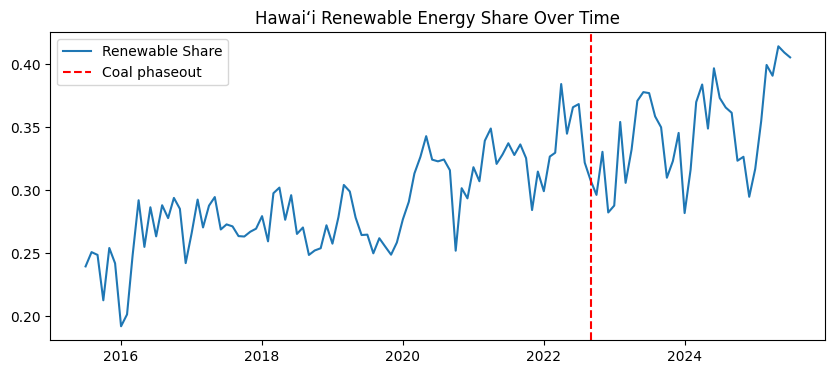

In [474]:
#renewable energy share over time in HI (past 10 years), red line is coal shutdown
plt.figure(figsize=(10,4))

plt.plot(ml_last10['date'], ml_last10['renewable_share'], label='Renewable Share')
plt.axvline(pd.to_datetime('2022-09-01'), color='red', linestyle='--', label='Coal phaseout')
plt.title("Hawaiʻi Renewable Energy Share Over Time")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    renewable_share   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 191.905
Date:                            Thu, 11 Dec 2025   AIC                           -371.810
Time:                                    09:40:14   BIC                           -357.297
Sample:                                07-01-2015   HQIC                          -365.979
                                     - 06-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
post_coal     -0.0243      0.022     -1.118      0.264      -0.067       0.018
ar.L1          0.1177      0.158   

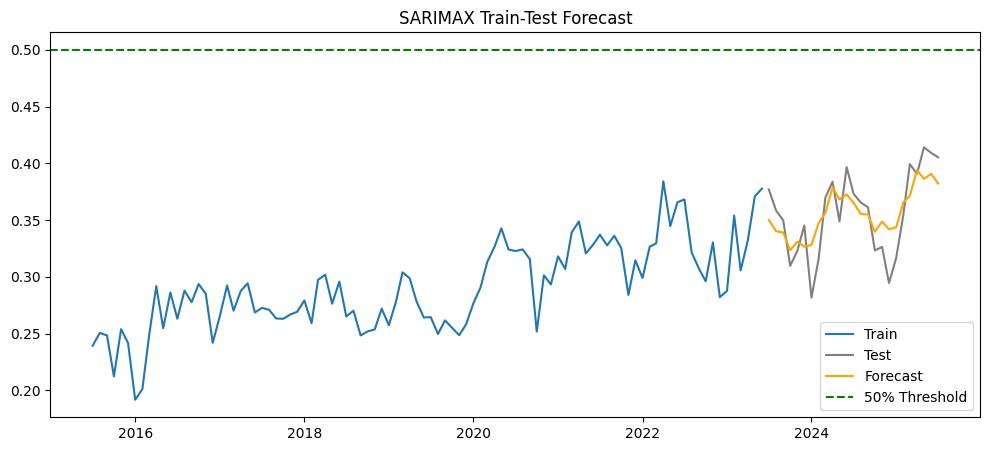

/tmp/ipython-input-1618291987.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=ml_last10['date'].max(), periods=steps+1, freq='M')[1:]


Renewables projected to meet/exceed nonrenewables in 2032.


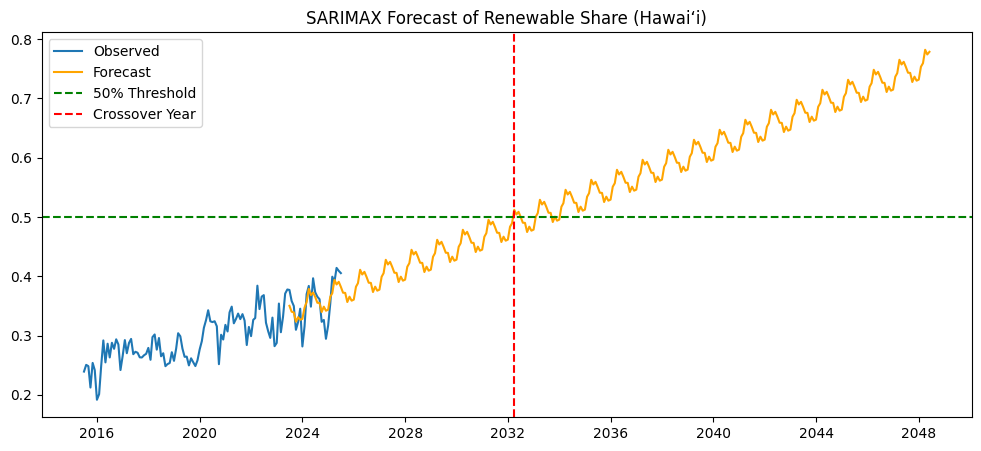

In [475]:
#defining target and exog (post_coal)
y = ml_last10.set_index('date')['renewable_share']
exog = ml_last10.set_index('date')[['post_coal']]

#train test split 80%
train_size = int(len(y) * 0.8)  # 80% train, 20% test
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
exog_train, exog_test = exog.iloc[:train_size], exog.iloc[train_size:]

#fitting SARIMAX on training data
model_10yr = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12), exog=exog_train)
fit = model_10yr.fit(disp=False)
print(fit.summary())

#forcasting for test period
forecast_test = fit.get_forecast(steps=len(y_test), exog=exog_test)
pred_test = forecast_test.predicted_mean.clip(0,1)

#plotting train vs test
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test', color='gray')
plt.plot(y_test.index, pred_test, label='Forecast', color='orange')
plt.axhline(0.5, color='green', linestyle='--', label='50% Threshold')
plt.legend()
plt.title("SARIMAX Train-Test Forecast")
plt.show()

#forecasting into future (300 steps)
steps = 300
future_dates = pd.date_range(start=ml_last10['date'].max(), periods=steps+1, freq='M')[1:]
future_exog = pd.DataFrame({'post_coal': 1}, index=future_dates)

forecast_future = fit.get_forecast(steps=steps, exog=future_exog)
pred_mean = forecast_future.predicted_mean.clip(0,1)

#combining past + future forecast
combined = pd.concat([y, pred_mean.rename('forecast')])

#first time forecast is >= 0.5
crossover = combined[combined >= 0.5].index[0]
print(f"Renewables projected to meet/exceed nonrenewables in {crossover.year}.")

#plotting full series with future forecast
plt.figure(figsize=(12,5))
plt.plot(ml_last10['date'], y, label='Observed')
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='orange')
plt.axhline(0.5, color='green', linestyle='--', label='50% Threshold')
plt.axvline(crossover, color='red', linestyle='--', label='Crossover Year')
plt.legend()
plt.title("SARIMAX Forecast of Renewable Share (Hawaiʻi)")
plt.show()


In [476]:
#model metrics
mae = mean_absolute_error(y_test, pred_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - pred_test) / y_test)) * 100

print(f"Performance on test set:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

Performance on test set:
MAE: 0.0194
MSE: 0.0005
RMSE: 0.0224
MAPE: 5.66%


Based on the final model, it is predicted that renewable energy in HI will first meet the amount of non-renewable energy in the year 2032, which is halfway to the state's 100% goal aimed for 2045.